# Low overhead error detection using spacetime codes

In this tutorial, we will implement a workflow to sample from a Clifford circuit and use the ``qiskit-paulice`` package to boost the fidelity of the measured distribution by applying [spacetime Pauli checks](https://arxiv.org/abs/2504.15725) throughout the circuit. Spacetime Pauli checks are similar to [coherent Pauli checks (CPC)](https://arxiv.org/abs/2212.03937) in that a Clifford "payload" circuit is entangled to some ancillary qubits in order to "check" certain invariants in the circuit. Measurement of the ancillas produces a syndrome that is used to determine whether a logical error was detected during execution of the circuit. Postselecting only samples where no error was detected can improve the fidelity of sampled distributions at the expense of decreasing postselection rates. The key difference between CPC and spacetime checks is that measuring CPC syndromes requires measuring time localized, high weight operators. On qubit topologies with limited connectivity, such as heavy hex, implementing these checks requires many SWAP gates, often making the circuit too deep to run in practice. Implementing Pauli checks as spacetime codes allows them to be distributed throughout the payload circuit, allowing for a hardware efficient qubit encoding that remains effective at detecting logical errors during circuit execution. The primary role of the ``qiskit-paulice`` package is to find and insert valid spacetime Pauli checks into locations in the circuit that both maximize error detection effectiveness and minimize qubit overhead.

This tutorial implements a workflow for boosting the fidelity of the distribution sampled from a quantum circuit using spacetime checks. Since we will use a Clifford circuit, we can estimate the fidelity straightforwardly from the averaged expectation values of the stabilizers of the circuit. We will follow these steps:

1. **Create a circuit**: Shallow 1D brickwork random Clifford circuit used to visualize the checks.
2. **Identify qubits as targets for checks**: Map the circuit to physical qubits on the ``ibm_boston`` Heron QPU and identify qubits with neighboring ancillas.
3. **Transpile the circuit to the backend**: Select a qubit layout and translate the circuit gates into the native gate set of ``ibm_boston``.
4. **Create a noise model from backend data**: Generate a rough noise model based on backend benchmark data. This noise data will be used to score the effectiveness of each additional check.
5. **Visualize Pauli checks**: Add some Pauli checks to the shallow circuit, so we can visualize how the checks are added.
6. **Determine stabilizers to measure**: Increase the depth of the circuit to increase the impact of gate noise. Randomly sample a subset of stabilizers of the deeper circuit.
7. **Find good checks for the whole state**: Find one set of checks for the stabilizers of the state the circuit prepares. Such checks are valid whatever is measured afterwards, so the same checked circuit serves every sampled stabilizer.
8. **Sample from the noisy circuit**: Measure the bare and checked circuits in the basis of each sampled stabilizer with [samplomatic](https://github.com/Qiskit/samplomatic), and sample them with the ``Executor`` primitive on a noisy simulator that uses the same depolarizing noise that was used to find the checks.
9. **Postselect checked circuit samples with no detected errors**: Remove samples which fail at least one check. Calculate expectation values for the bare noisy circuit and the circuit containing checks.
10. **Compare fidelities of original and postselected noisy states**: Show that postselecting only samples with no detected errors improves the estimated fidelity of the noisy state.

### 1. Create the circuit

First, we will create a shallow Clifford circuit with its entangling gates laid out in a brickwork connectivity. We will use this small circuit to visualize how checks are added to the circuit.

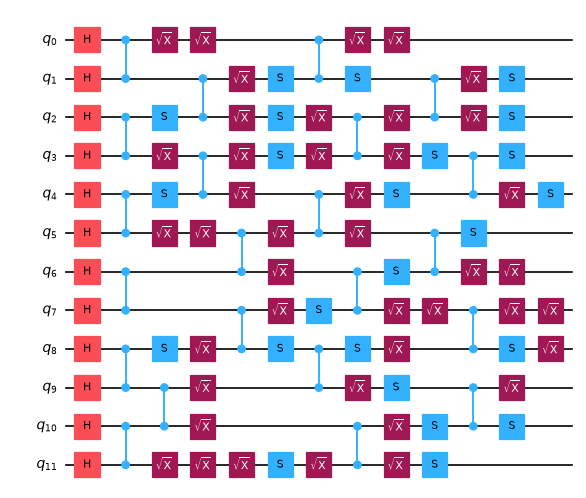

In [1]:
import numpy as np
from qiskit import QuantumCircuit


def random_clifford_circuit(
    num_qubits: int, depth: int, rng: np.random.Generator
) -> QuantumCircuit:
    """Brickwork random Clifford on `num_qubits`, with `depth` CZ layers."""
    qc = QuantumCircuit(num_qubits)
    qc.h(range(num_qubits))
    for d in range(depth):
        for i in range(d % 2, num_qubits - 1, 2):
            qc.cz(i, i + 1)
        for q in range(num_qubits):
            if rng.integers(0, 2):
                qc.sx(q)
            if rng.integers(0, 2):
                qc.s(q)
            if rng.integers(0, 2):
                qc.sx(q)
    return qc


num_qubits = 12
depth = 4
seed = 1764
rng = np.random.default_rng(seed)
np.random.seed(seed)
circuit = random_clifford_circuit(num_qubits, depth, rng)
circuit.draw("mpl", fold=-1, scale=0.6)

### 2. Identify qubits as targets for checks

Next we choose a 1D qubit layout on the Heron r3 QPU, ``ibm_boston``. We choose a layout that zig-zags diagonally through the coupling graph and maximizes the number of available ancilla qubits. To find available ancillas, we use the ``get_check_qubits`` function, which returns lists of target/ancilla qubit pairs. A Pauli check on ``target_qubits[i]`` will be implemented using ``ancilla_qubits[i]``.

In the coupling graph below, the green qubits are the payload qubits, and the orange qubits are the ancillas we will use to implement the checks. Qubits ``68``, ``69``, ``89``, ``91``, ``111``, ``113``, and ``133`` have adjacent ancillas, so we will use those qubits (corresponding to virtual qubits ``0``, ``1``, ``3``, ``5``, ``7``, ``9``, and ``11``) as target qubits for implementing checks. Note that qubit ``134`` is adjacent to qubit ``133`` in the payload but not highlighted as an ancilla. This is because ``133`` was already (arbitrarily) chosen to implement a check with ancilla ``132``.

Target qubits:  [68, 69, 89, 91, 111, 113, 133]
Ancilla qubits: [67, 70, 88, 92, 110, 114, 132]


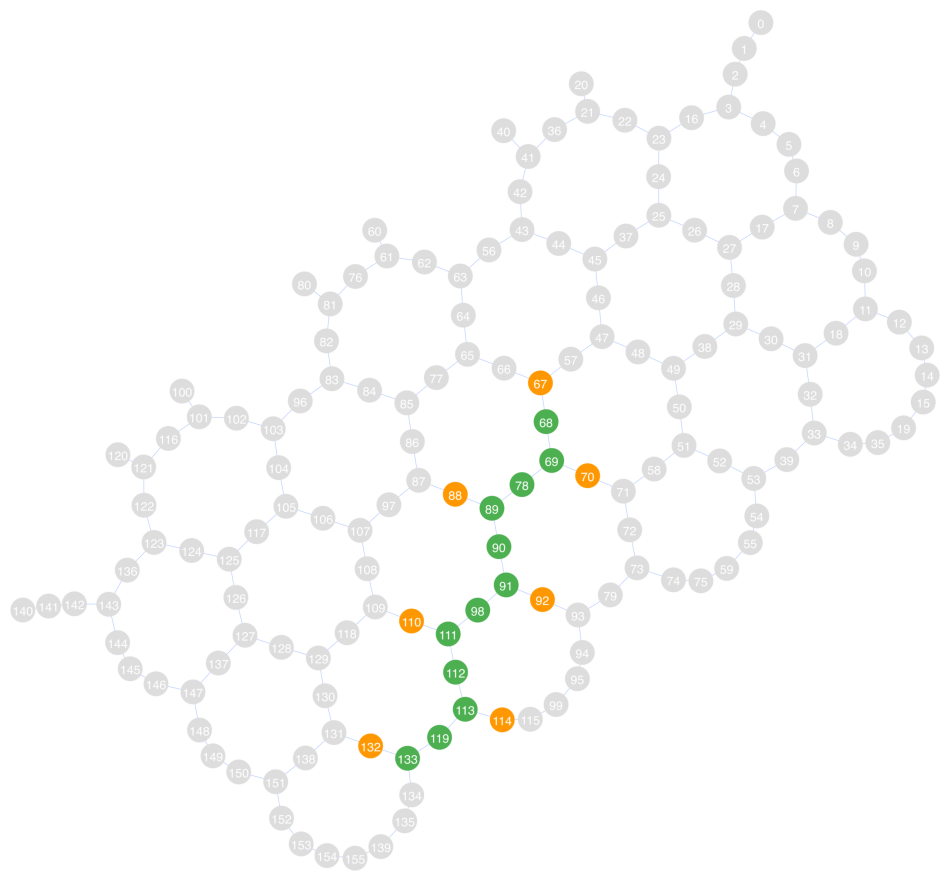

In [2]:
from qiskit.visualization import plot_coupling_map
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_paulice.layout import get_check_qubits

service = QiskitRuntimeService()
backend = service.backend("ibm_boston")

# Choose a layout and pair each available target qubit with a neighboring ancilla
layout = [68, 69, 78, 89, 90, 91, 98, 111, 112, 113, 119, 133]
target_qubits, ancilla_qubits = get_check_qubits(backend, layout)

print(f"Target qubits:  {target_qubits}")
print(f"Ancilla qubits: {ancilla_qubits}")
plot_coupling_map(
    num_qubits=backend.num_qubits,
    qubit_coordinates=getattr(backend.configuration(), "qubit_coordinates", None),
    coupling_map=backend.configuration().coupling_map,
    figsize=(12, 12),
    qubit_color=[
        "#4CAF50" if i in set(layout) else "#FF9800" if i in set(ancilla_qubits) else "#DDDDDD"
        for i in backend.coupling_map.graph.node_indices()
    ],
    qubit_size=220,
    line_width=2,
    font_size=90,
)

### 3. Transpile the circuit to the backend

Since the backend has already been chosen, we can go ahead and transpile our virtual circuit into an ISA circuit. Here, we just set the qubit layout and translate the gates into the native gate set of ``ibm_boston``.

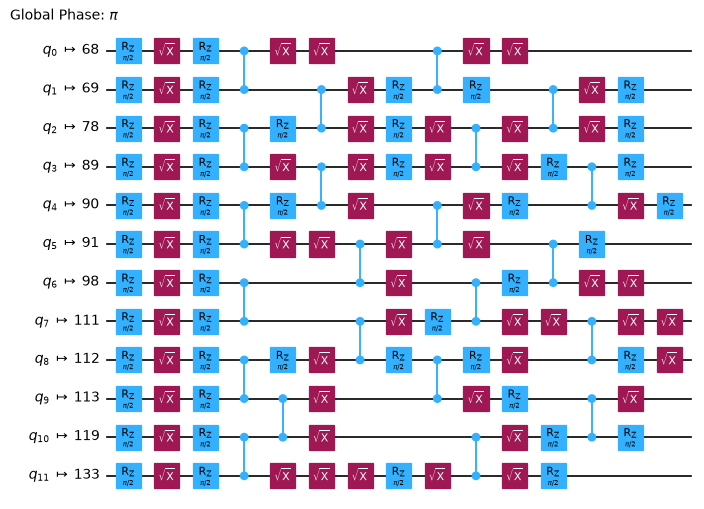

In [3]:
from qiskit.transpiler import generate_preset_pass_manager

pm = generate_preset_pass_manager(optimization_level=0, backend=backend, initial_layout=layout)
circuit_isa = pm.run(circuit)
circuit_isa.draw("mpl", fold=-1, scale=0.6)

### 4. Create a noise model from backend data

Now that we know how the circuit will be laid out on the QPU, we can model how the gate and readout noise on the backend will affect circuit execution. The noise model is used to determine optimal places in the circuit to place Pauli checks. We want to place checks in positions where they capture the maximum amount of error. While a more accurate noise model can improve the detection capabilities of the checks, it is usually not necessary to learn a noise model by sampling the QPU. Here we infer a uniform depolarizing gate noise model using only backend benchmark data from ``qiskit-ibm-runtime``, and drop the readout error it also reports: the checks we find in step 7 read only their ancilla, so payload readout errors are invisible to them and would only lower the postselected fidelity in step 10. See the ``qiskit_paulice.NoiseModel`` documentation for more information on specifying gate and readout noise. For users who wish to use a learned Pauli-Lindblad noise model, see ``NoiseModel.from_pauli_lindblad_maps``.

In [4]:
from dataclasses import replace

from qiskit_paulice.noise_models import NoiseModel

# Model the gate noise as a uniform depolarizing channel based on backend benchmark data
noise_model = replace(
    NoiseModel.from_backend(backend, layout, uniform_gate_noise=True), readout_noise=None
)
print(noise_model)

NoiseModel(gate_noise=0.0015808382794757693, readout_noise=None, idling_noise=None)


### 5. Visualize Pauli checks

Now let's add some checks to the circuit and see how they look. We can use the ``qiskit_paulice.add_pauli_checks`` function to find a good set of valid checks. We provide the Clifford payload circuit as input, along with a list of payload qubits on which to add checks (target qubits) and the noise model we made in the previous step. In this example, we will add checks to all ``7`` target qubits with available ancillas. **Checks are added to qubits in the order they appear in ``target_qubits``, which makes it easy to reason about the final layout of the checked circuit: ``final_layout = layout + ancilla_qubits``. If a user decides they would prefer to run one of the output circuits with fewer (``i``) checks, the final layout would be ``final_layout = layout + ancilla_qubits[:i+1]``.**

The circuit visualization shows that the checks were correctly implemented using the specified target/ancilla pairs.

Details on ``qiskit_paulice.add_pauli_checks``:
- The first input should be a Clifford circuit. Here it has no measurements and we pass ``stabilizers="all"``, so the checks are found for the stabilizers of the state the circuit prepares: a check is valid if its spacetime Pauli product measures such a stabilizer, its syndrome is its ancilla bit alone, and it stays valid whatever basis the payload is measured in afterwards. This is what a fidelity estimation needs, since every sampled stabilizer is measured in a different basis. (Omitting ``stabilizers`` instead finds checks for a circuit's terminal measurements.)
- The second positional argument is a list of target qubit indices. Each target qubit will share entangling gates with an ancilla qubit to form a check. Checks will be found and added to the circuit in the order they are given in this argument.
- The final positional argument is a noise model representing the noise expected to affect the circuit during execution. This model is used to evaluate the effectiveness of a given check.
- ``ancilla_qubits``: If the input circuit has a layout, this kwarg instructs ``add_pauli_checks`` on how to assign physical qubits to newly added ancillas. ``ancilla_qubits`` should be the same length as ``target_qubits`` (2nd positional arg), and ``ancilla_qubits[i]`` should be used to implement checks on ``target_qubits[i]``.
- ``cost``: The cost function used to evaluate checks. Can be ``gamma`` or ``LER`` (logical error rate), which are all ways to describe how much of the noise channel is left undetected by the checks. With ``stabilizers="all"`` an error counts as logical if it changes the prepared state, which is exactly what the fidelity measures.
- ``method``: The method used to find valid checks. We use ``windowed`` which randomly samples many spatial window subsets of a target qubit's support (wires). Other valid values are ``genetic`` and ``windowed_genetic``.
- The output of ``add_pauli_checks`` contains circuits with increasing numbers of checks, from a circuit with no checks to a circuit with checks on every target qubit (assuming valid checks are found).

See [Sections II-IV of the supplementary information](https://arxiv.org/abs/2504.15725) for detailed information on finding good spacetime Pauli checks

Physical layout of payload+ancillas: [68, 69, 78, 89, 90, 91, 98, 111, 112, 113, 119, 133, 67, 70, 88, 92, 110, 114, 132]
Checked circuit:


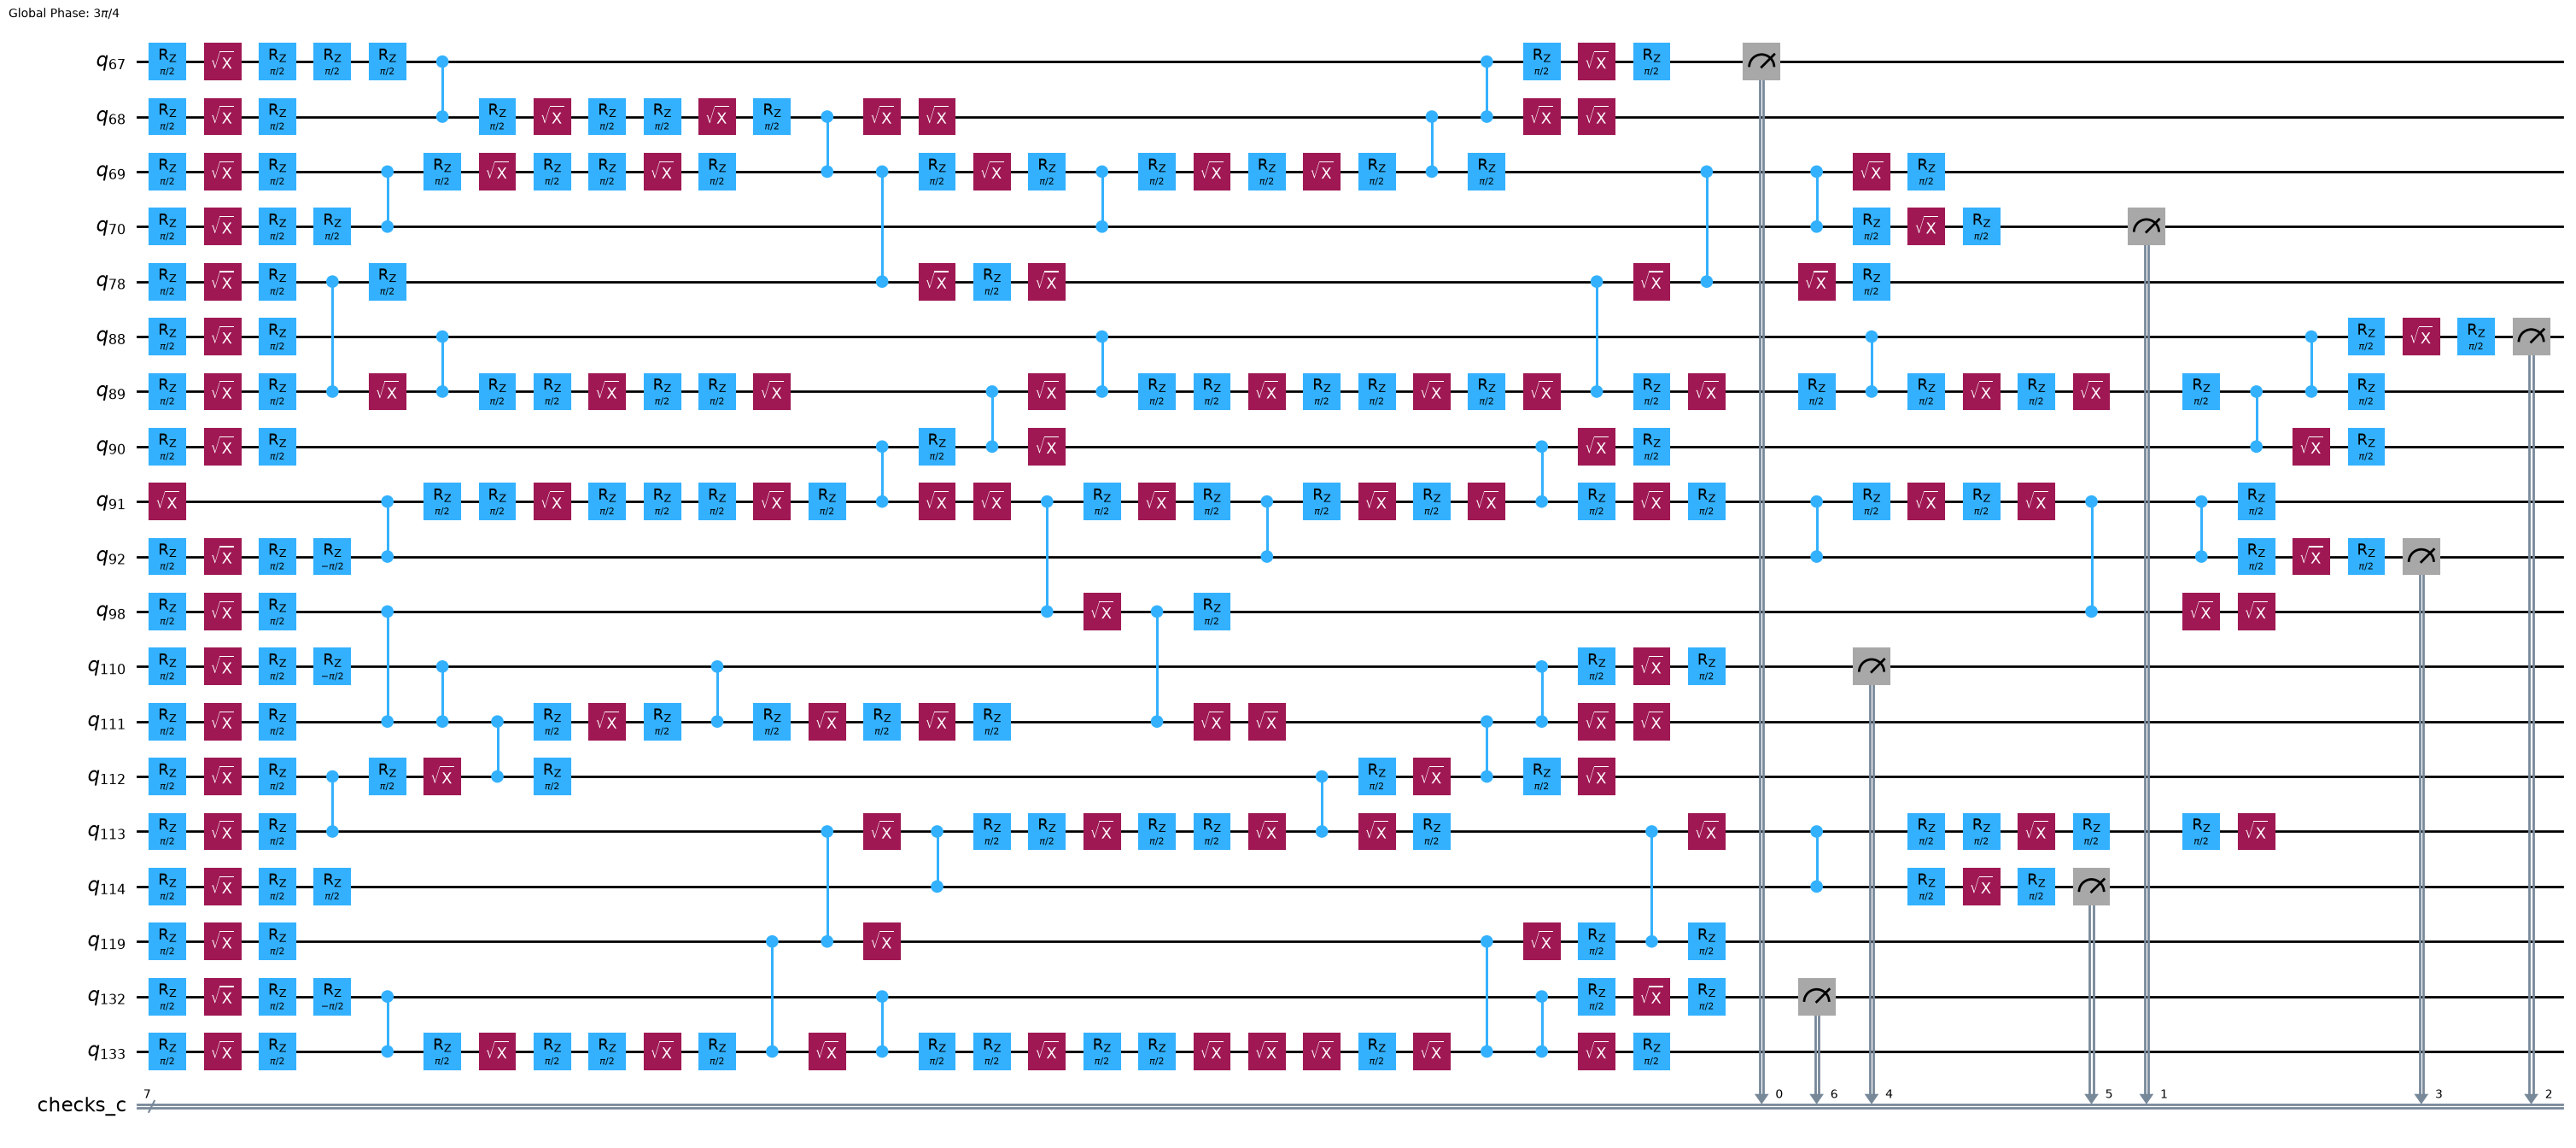

In [5]:
import matplotlib.pyplot as plt
from qiskit_paulice import add_pauli_checks

# Find checks on circuit
checked = add_pauli_checks(
    circuit_isa,
    target_qubits,
    noise_model,
    ancilla_qubits=ancilla_qubits,
    cost="gamma",
    method="windowed",
    seed=seed,
    stabilizers="all",
)

print(f"Physical layout of payload+ancillas: {layout + ancilla_qubits}")
print("Checked circuit:")
checked[-1].circuit.draw("mpl", fold=-1, idle_wires=False)

### 6. Determine stabilizers to measure

To test the performance of the error detection we will estimate the fidelity of the stabilizer state, $|\psi\rangle = U|0\rangle^{\otimes n}$, that the circuit ideally prepares against the noisy state, $\rho$, the hardware actually outputs. The projector onto the pure stabilizer state, $|\psi\rangle$, is defined to be the uniform average over the $2^n$ elements of its stabilizer group $\mathcal{S}$:

$$|\psi\rangle\langle\psi| = \frac{1}{2^n}\sum_{G \in \mathcal{S}} G$$

Plugging this into the fidelity equation, we see that the fidelity of noisy state, $\rho$, is equivalent to the average expectation value of all stabilizers, $G \in \mathcal{S}$, with respect to $\rho$:

$$F = \mathrm{Tr}(\rho|\psi\rangle\langle\psi|) = \mathrm{Tr}({\frac{1}{2^n}\sum_{G \in \mathcal{S}} \rho G}) = \frac{1}{2^n} \sum_{G \in \mathcal{S}} \mathrm{Tr}(\rho G) = \frac{1}{2^n} \sum_{G \in \mathcal{S}} \langle G \rangle_\rho$$

For larger problems, measuring (or even enumerating) all $2^n$ stabilizers is infeasible, so fidelity is often estimated by measuring a random sample of stabilizers. Sampling $M$ stabilizers $G_1, \ldots, G_M$ uniformly at random from $\mathcal{S}$ gives an unbiased estimator of the fidelity, $\hat F_M$,

$$\hat F_M = \frac{1}{M} \sum_{i=1}^M \langle G_i \rangle_\rho$$
For this experiment we will make the circuit much deeper to enhance the effect of gate noise, and we will add checks to every qubit with a neighboring ancilla qubit. While there are more sophisticated ways to sample stabilizers to estimate fidelity, in this example we will sample $100$ stabilizers with uniform probability.

In [6]:
from qiskit.quantum_info import Clifford, Pauli, PauliList

num_stabilizers = 100
num_shots = 1_000
num_checks = len(target_qubits)
depth = 72

circuit = random_clifford_circuit(num_qubits, depth, rng)
# Create all 2^N stabilizers
stabilizers = PauliList([Pauli("I" * num_qubits)])
for generator in (Pauli(label) for label in Clifford(circuit).to_labels(mode="S")):
    stabilizers = stabilizers + stabilizers.compose(generator)

# Choose some random stabilizers from the set
keep = np.where(stabilizers.x.any(axis=1) | stabilizers.z.any(axis=1))[0]
chosen = np.random.default_rng(seed).choice(
    keep, size=min(num_stabilizers, len(keep)), replace=False
)
stabilizers = stabilizers[chosen]
depth = circuit.depth(lambda x: x.operation.num_qubits == 2)
print(
    f"Sampled {len(stabilizers)} stabilizers of {circuit.num_qubits}-qubit circuit with two-qubit depth of {depth}: {{{stabilizers[0]}, {stabilizers[1]}, ...}}"
)

Sampled 100 stabilizers of 12-qubit circuit with two-qubit depth of 72: {-YIIYZZZIZIYY, -XIXYIIZXYIZX, ...}


### 7. Find good checks for the whole state

We find one set of checks for the deep circuit exactly as in step 5. Since the checks read only their ancillas, the same checked circuit serves every sampled stabilizer. The returned circuits measure only the check ancillas, so we will add the payload measurements in the next step.

In [7]:
import time

# Transpile the deep payload without measurements and find one set of checks for the whole state
payload_isa = pm.run(circuit)
t0 = time.time()
checked = add_pauli_checks(
    payload_isa,
    target_qubits,
    noise_model,
    ancilla_qubits=ancilla_qubits,
    cost="gamma",
    method="windowed",
    seed=seed,
    stabilizers="all",
)
print(f"Added {len(checked[-1].check_qubits)} checks in {time.time() - t0:.0f}s.")
print(
    f"2-qubit depth increased from {payload_isa.depth(lambda x: len(x.qubits) == 2)} to "
    f"{checked[-1].circuit.depth(lambda x: len(x.qubits) == 2)} when adding {num_checks} checks."
)

Added 7 checks in 3s.
2-qubit depth increased from 72 to 85 when adding 7 checks.


### 8. Sample from the noisy circuit

We sample every variant, from the bare payload to the circuit with all ``7`` checks, for each sampled stabilizer. The variant with zero checks is the bare payload with the same measurements, so it serves as the noisy reference. Instead of appending the basis rotation of every stabilizer to a copy of every variant, we let [samplomatic](https://github.com/Qiskit/samplomatic) choose the measurement basis at sampling time. For each variant we:

- Measure the payload and group the terminal measurements into a box with samplomatic's boxing pass manager. The box carries a ``ChangeBasis`` annotation, so ``build`` returns a template circuit whose basis-changing gates are parameterized, along with a samplex that computes the parameters for a requested basis.
- Add the template and samplex to a ``QuantumProgram``. The samplex takes one measurement basis per qubit in the box, in ascending physical order, encoded as $I=0$, $Z=1$, $X=2$, $Y=3$. Passing an array of bases with a leading axis of length ``100`` makes a single item measure all ``100`` stabilizers: the payload in each stabilizer's basis and the ancillas in $Z$. A qubit outside a stabilizer's support is also measured in $Z$, and its bit is ignored when the stabilizer's expectation value is computed.

The ``Executor`` primitive from ``qiskit-ibm-runtime`` runs the whole program in one job. Given an ``AerSimulator`` in place of a QPU it runs locally on that simulator, so we hand it one with the same depolarizing gate noise we used to find the checks, and use the stabilizer method since all of the circuits are Clifford. Qiskit Aer is needed only to build this simulator: the local mode takes the seed from the ``Executor`` options but ignores their ``noise_model``, so the noise must be set on the simulator itself. Passing a QPU backend instead would run the same program on hardware. Once the simulations are complete, we will calculate the postselection rate and expectation values to get a feel for how well the error detection worked before visualizing the data.

In [8]:
from qiskit import ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel as AerNoiseModel
from qiskit_aer.noise import depolarizing_error
from qiskit_ibm_runtime import Executor
from qiskit_ibm_runtime.quantum_program import QuantumProgram
from samplomatic.builders import build
from samplomatic.transpiler import generate_boxing_pass_manager

# Group the terminal measurements into a box whose measurement basis is chosen at sampling time
boxing_pm = generate_boxing_pass_manager(enable_gates=False, measure_annotations="change_basis")

# bases[i, q]: basis in which physical qubit q is measured for stabilizer i (I=0, Z=1, X=2, Y=3)
bases = np.ones((len(stabilizers), backend.num_qubits), dtype=np.uint8)
bases[:, layout] = stabilizers.z + 2 * stabilizers.x

program = QuantumProgram(shots=num_shots)
for variant in checked:
    circ = variant.circuit.copy()
    circ.add_register(meas := ClassicalRegister(num_qubits, "meas"))
    circ.measure(layout, meas)
    template, samplex = build(boxing_pm.run(circ))
    (basis_input,) = samplex.inputs().get_specs()
    measured_qubits = sorted(layout + list(variant.check_qubits))
    program.append_samplex_item(
        template,
        samplex=samplex,
        samplex_arguments={basis_input.name: bases[:, measured_qubits]},
        shape=(len(stabilizers),),
    )

# Simulate the program with the same gate noise we used to find the checks
aer_nm = AerNoiseModel()
aer_nm.add_all_qubit_quantum_error(depolarizing_error(noise_model.gate_noise, 2), ["cz"])
noisy_sim = AerSimulator(method="stabilizer", noise_model=aer_nm)

# outs[k][register]: bits of the variant with k checks, shape (stabilizers, shots, bits)
t0 = time.time()
outs = Executor(noisy_sim, options={"simulator": {"seed_simulator": seed}}).run(program).result()
print(
    f"Sampled {len(checked)} circuits for {len(stabilizers)} stabilizers in {time.time() - t0:.0f}s."
)

Sampled 8 circuits for 100 stabilizers in 77s.


### 9. Postselect checked circuit samples

In this package a check is implemented using entangling gates between one ancilla qubit and one target qubit. Each ancilla starts in $|0\rangle$, so $Z_\text{anc}$ stabilizes its input state. Forward propagating $Z_\text{anc}$ from the beginning of the ancilla through the entire checked circuit yields $Z_\text{anc}$ times a stabilizer of the prepared state, so the check passes if the ancilla bit is $0$. A sample is kept if every check passes.

The checked circuits measure the ancillas into the ``checks_c`` register, so a sample is kept if every bit of that register is ``0``. In general, the ``get_postselection_method`` method of the ``CheckedCircuit`` instances output from ``add_pauli_checks`` maps a shot's bitstring to the syndrome of every check at once; for checks found for the stabilizers of the prepared state, each syndrome is just its ancilla bit, so we read the register directly.

In the chart, we see that adding more checks causes the postselection rate to go down. While the goal of error detection is to catch as many errors as possible, as postselection rate goes down more shots may be required to achieve some target accuracy. If the postselection rate drops too low, the number of shots needed to collect one logical sample may become prohibitive. In this example, the postselection rate seems to converge, implying that additional checks are contributing less additional detection capability. Although adding more Pauli checks generally provides greater error detection capability, it comes at a cost of increased circuit depth and an increase in sampling cost.

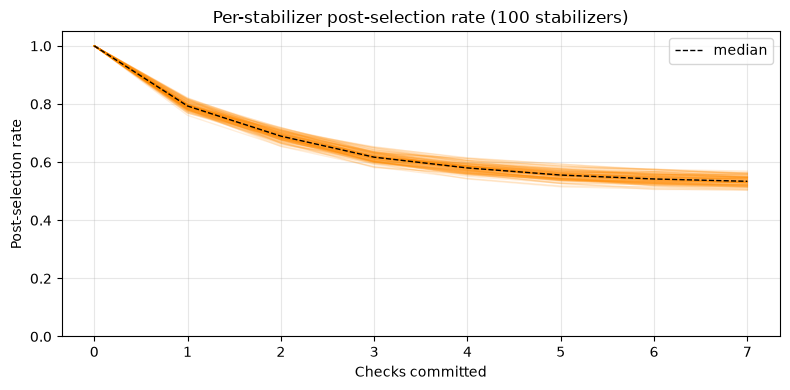

In [9]:
def keep_mask(out):
    """Per-shot True/False: every ancilla read 0, so every Pauli check passed."""
    if "checks_c" not in out:  # the bare payload has no checks
        return np.ones(out["meas"].shape[:-1], dtype=bool)
    return ~out["checks_c"].any(axis=-1)


# masks[k][i]: kept shots of stabilizer i measured on the variant with k checks
masks = [keep_mask(out) for out in outs]
psrs_arr = np.array([mask.mean(axis=-1) for mask in masks]).T
ks = np.arange(psrs_arr.shape[1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, psrs_arr.T, color="darkorange", alpha=0.15, linewidth=1)
ax.plot(
    ks,
    np.median(psrs_arr, axis=0),
    color="black",
    linewidth=1,
    linestyle="--",
    label="median",
)
ax.set(
    xlabel="Checks committed",
    ylabel="Post-selection rate",
    ylim=(0, 1.05),
    title=f"Per-stabilizer post-selection rate ({len(psrs_arr)} stabilizers)",
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 10. Compare fidelities of original and postselected noisy states

We see that postselecting only samples with no detected errors greatly improves the expectation value for every stabilizer, and thus improves the estimated fidelity of the stabilizer state. Although the postselected values were calculated using only the samples that passed every check, the expectation values are much more accurate and the sampled variance is lower. We can also now see that the postselection rate above was actually converging to a value similar to the noisy circuit fidelity. The postselection rate was converging because the checks were catching the vast majority of errors actually occuring during circuit execution.

ideal fidelity: 1.0
noisy fidelity: 0.5582
postselected fidelity: 0.9747
mean post-sel rate: 0.535



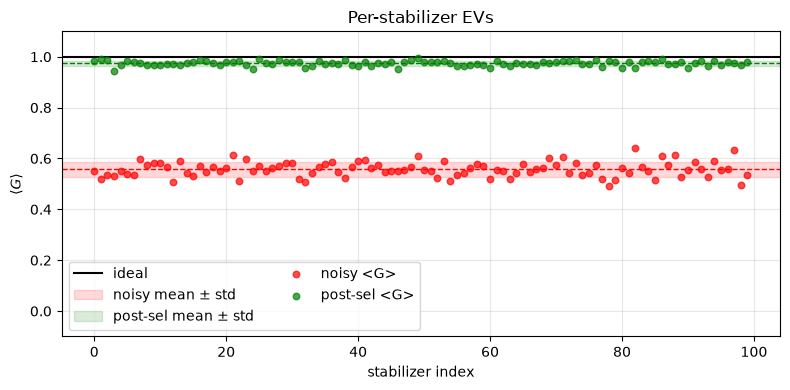

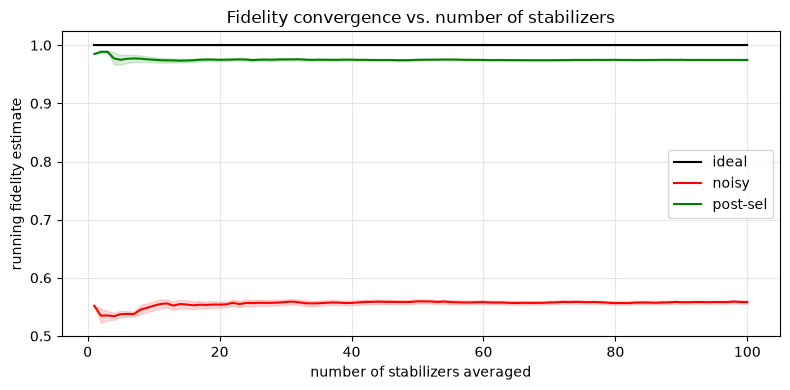

In [10]:
def expectation_values(out, mask):
    """EV of each stabilizer from the shots of ``out`` kept by ``mask``.

    Bit q of ``meas`` is virtual qubit q, so a stabilizer's eigenvalue in a shot is the parity of
    the bits in its support, times its sign.
    """
    support = stabilizers.x | stabilizers.z
    parity = (out["meas"] & support[:, None, :]).sum(axis=-1) % 2
    signs = np.where(stabilizers.phase == 2, -1.0, 1.0)
    eigenvalues = np.where(parity, -1.0, 1.0) * signs[:, None]
    kept = mask.sum(axis=-1)
    return np.where(kept > 0, (eigenvalues * mask).sum(axis=-1) / np.maximum(kept, 1), np.nan)


evs_noisy = expectation_values(outs[0], masks[0])
evs_post = expectation_values(outs[-1], masks[-1])
print(
    f"ideal fidelity: 1.0\n"
    f"noisy fidelity: {np.nanmean(evs_noisy):.4f}\n"
    f"postselected fidelity: {np.nanmean(evs_post):.4f}\n"
    f"mean post-sel rate: {masks[-1].mean():.3f}\n"
)

evs_ideal = np.ones(len(stabilizers))
idx = np.arange(len(stabilizers))


def cum_mean_sem(ys):
    valid = ~np.isnan(ys)
    s = np.cumsum(np.where(valid, ys, 0.0))
    s2 = np.cumsum(np.where(valid, ys**2, 0.0))
    n = np.maximum(np.cumsum(valid).astype(float), 1)
    mean = s / n
    sem = np.sqrt(np.maximum(s2 / n - mean**2, 0) / n)
    return np.where(np.cumsum(valid) > 0, mean, np.nan), sem


def strip(ax, ys, color, label):
    m, s = np.nanmean(ys), np.nanstd(ys)
    ax.axhspan(m - s, m + s, color=color, alpha=0.15, label=f"{label} mean ± std")
    ax.axhline(m, color=color, linewidth=1, linestyle="--")


fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(np.nanmean(evs_ideal), color="black", linewidth=1.5, label="ideal")
strip(ax, evs_noisy, "red", "noisy")
strip(ax, evs_post, "green", "post-sel")
ax.scatter(idx, evs_noisy, color="red", s=22, alpha=0.7, zorder=3, label="noisy <G>")
ax.scatter(idx, evs_post, color="green", s=22, alpha=0.7, zorder=3, label="post-sel <G>")
ax.set(
    xlabel="stabilizer index",
    ylabel=r"$\langle G \rangle$",
    ylim=(-0.1, 1.1),
    title="Per-stabilizer EVs",
)
ax.legend(loc="lower left", ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

M = np.arange(1, len(stabilizers) + 1)
fig, ax = plt.subplots(figsize=(8, 4))
for ys, color, label in [
    (evs_ideal, "black", "ideal"),
    (evs_noisy, "red", "noisy"),
    (evs_post, "green", "post-sel"),
]:
    cm, sem = cum_mean_sem(ys)
    ax.plot(M, cm, color=color, linewidth=1.5, label=label)
    ax.fill_between(M, cm - sem, cm + sem, color=color, alpha=0.15)
ax.set(
    xlabel="number of stabilizers averaged",
    ylabel="running fidelity estimate",
    title="Fidelity convergence vs. number of stabilizers",
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Since one set of checks serves every stabilizer, there is a single gamma curve to look at: the value of the cost function after each check was committed. For other problems on a different set of physical qubits, and with an imperfect noise model (remember, our noise model in this tutorial exactly modeled the noise affecting the samples), the order in which checks are added to the target qubits can have a more pronounced effect on how the curve converges.

This gamma curve converging to ``1.0`` implies that additional checks will not be able to detect a great deal of additional error, as there is very little modeled error that is uncovered by the checks. This reinforces our earlier observation regarding convergence in postselection rate being due to a lack of uncovered error in the circuit.

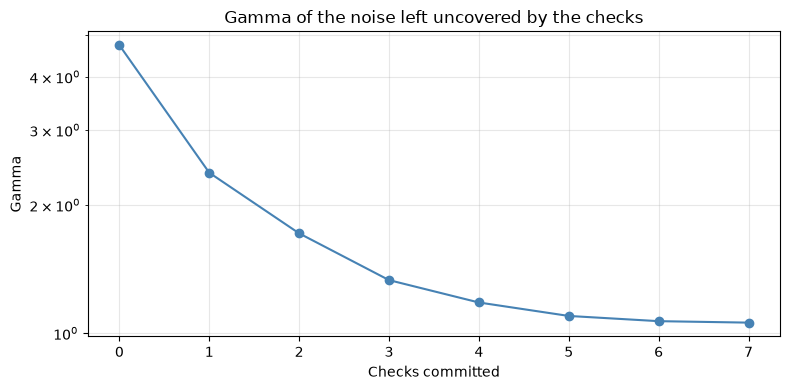

In [11]:
costs = [variant.cost for variant in checked]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(len(costs)), costs, color="steelblue", marker="o")
ax.set(
    xlabel="Checks committed",
    ylabel="Gamma",
    yscale="log",
    title="Gamma of the noise left uncovered by the checks",
)
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()